# Attention is all you need - Time series forecasting with Transformers

## Purpose

This notebook implements a Transformer-based model for univariate time series forecasting, built from scratch using PyTorch. The project is structured in two parts:

1. Synthetic data (Secs. I–V): we generate a composite sinusoidal signal with noise and use it to validate that the Transformer architecture can learn periodic patterns and produce accurate forecasts.

2. Real-world data (Secs. VI): we apply the same pipeline to daily gold prices (USD/Troy oz, 1995–2016), testing the model's ability to generalize beyond synthetic patterns.

## Key concepts covered

- Positional Encoding (sinusoidal, as defined in [Vaswani et al., 2017](https://arxiv.org/abs/1706.03762))
- Multi-Head Self-Attention and its role in capturing long-range dependencies
- Sliding window approach for sequence-to-point forecasting
- Autoregressive multi-step forecasting (deploy)
- Proper train/test normalization to avoid data leakage

## Tech stack

Python, PyTorch, NumPy, pandas, scikit-learn, Matplotlib

## Author

Gui Freire Oliveira

In [1]:
# Imports
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Global configs for the graphs 
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

In [3]:
# Device selection: prioritize CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Device selected: NVIDIA GPU (CUDA)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device selected: Apple GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Device selected: CPU")

print(f'Using device: {device}')

Device selected: CPU
Using device: cpu


# I - Preparing time series data

We generate a synthetic time series composed of three sinusoidal components with different periods and amplitudes, plus Gaussian noise. This controlled setup lets us validate the Transformer's ability to learn periodic patterns before moving to real-world data.

In [4]:
# Generate a synthetic time series with three sine components and noise
def timeseries(n_points = 2000):
    t = np.arange(n_points)

    # Fast oscillation (period 13) - captures short-term patterns
    tseries  = np.sin(2 * np.pi * t / 13)

    # Slow oscillation (period 98, double amplitude) - captures long-term trends
    tseries += 2 * np.sin(2 * np.pi * t / 98)

    # Gaussian noise (std=0.5) - simulates real-world measurement imperfections
    tseries += 0.5 * np.random.randn(n_points)

    return t, tseries

In [5]:
t, series = timeseries()
print(f"Length: {len(series)}\nType: {type(series)}\nFirst 5 values: {series[0:5]}")

Length: 2000
Type: <class 'numpy.ndarray'>
First 5 values: [-0.93598728  1.03582303  0.75611977  1.04892776  1.25284529]


## Visualize time series

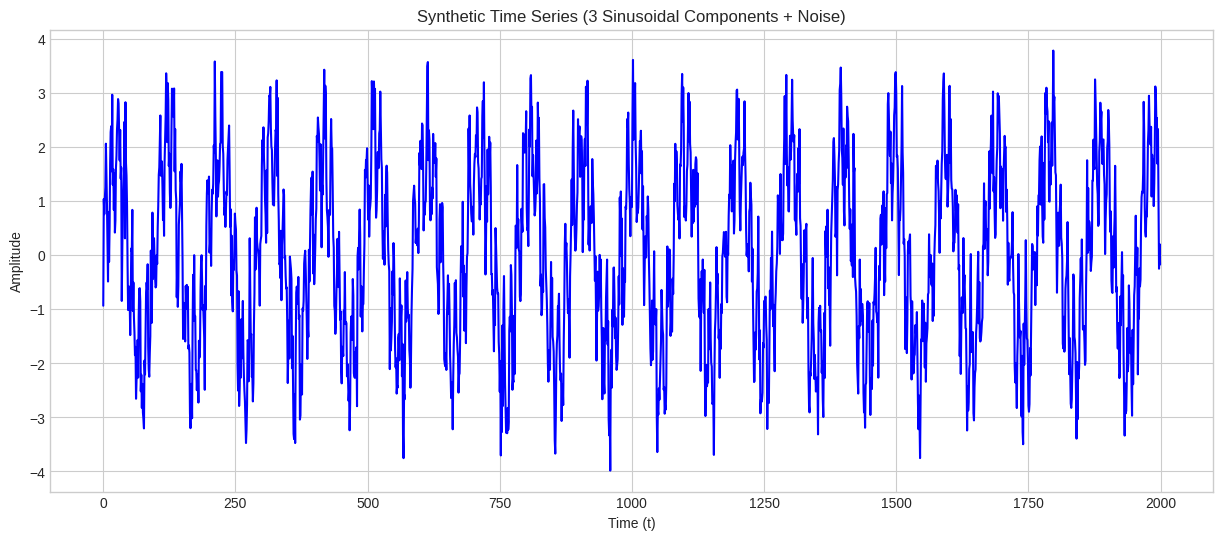

In [6]:
plt.figure(figsize = (15, 6))
plt.plot(t, series, color = 'blue', linewidth = 1.5)
plt.title("Synthetic Time Series (3 Sinusoidal Components + Noise)")
plt.xlabel("Time (t)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## Train/test split

In [7]:
# Sliding window size - must be large enough to capture the slowest period (~98)
input_window = 70

# Sequential 80/20 split - no shuffling to preserve temporal order
cutoff = int(len(series) * 0.8)

In [8]:
# Split preserving temporal sequence
series_train = series[:cutoff]
series_test  = series[cutoff:]

## Data normalization

In [9]:
# Normalize data to (-1, 1) - symmetric range matches the Positional Encoding scale
scaler = MinMaxScaler(feature_range = (-1, 1))

In [10]:
# Fit ONLY on training data to avoid data leakage
scaler.fit(series_train.reshape(-1, 1))

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(-1, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [11]:
# Apply the same transformation to both train and test
series_train_rescaled = scaler.transform(series_train.reshape(-1, 1)).astype(np.float32)
series_test_rescaled  = scaler.transform(series_test.reshape(-1, 1)).astype(np.float32)

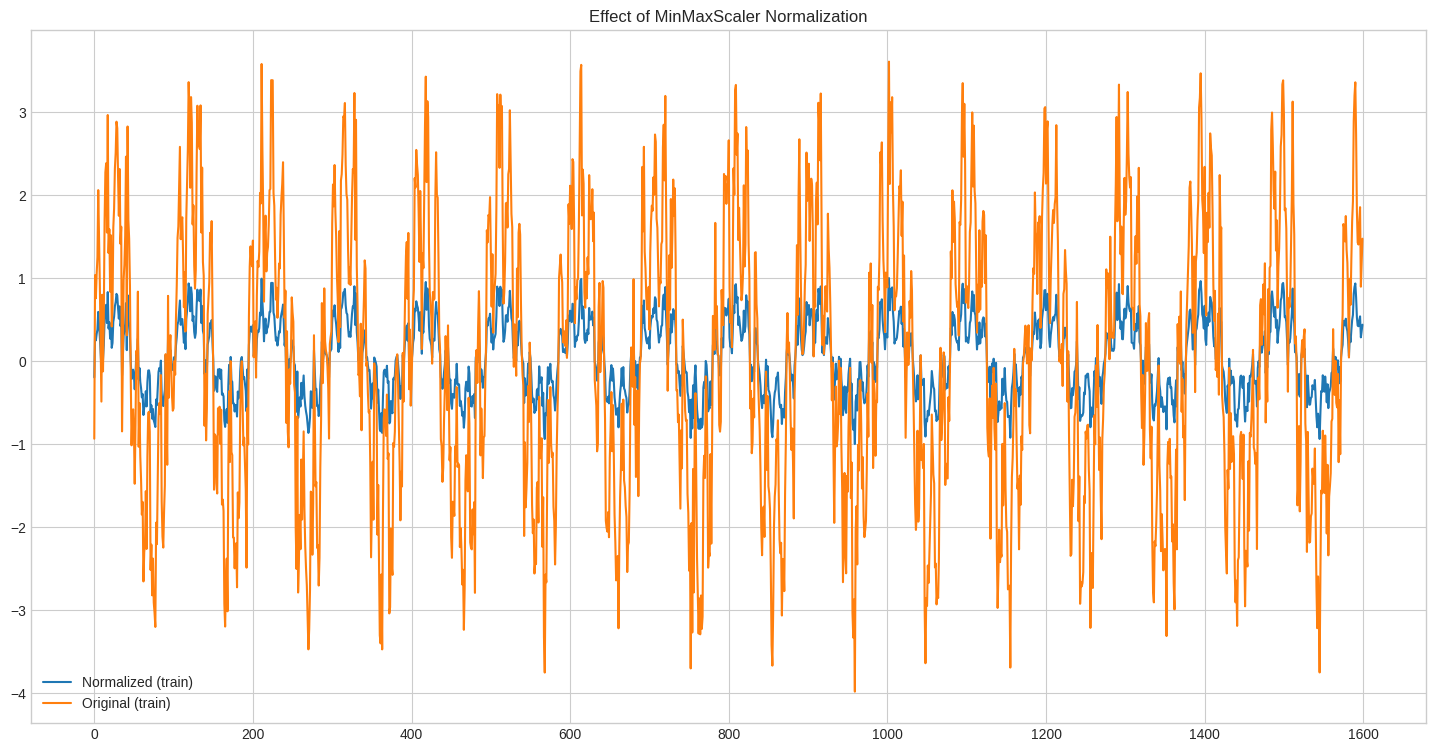

In [12]:
# Compare original vs. normalized signal
plt.figure(figsize = (18, 9))
plt.plot(t[:cutoff], series_train_rescaled, label = 'Normalized (train)')
plt.plot(t[:cutoff], series[:cutoff], label = 'Original (train)')
plt.legend()
plt.title("Effect of MinMaxScaler Normalization")
plt.show()

## Create data sequences

We use a sliding window approach to create input-output pairs. Each input is a sequence of `input_window` consecutive points, and the target is the immediately following point. The model learns: "given these 70 points, predict the next one."

Structure: `(sequence[size=70], next_point)`

In [13]:
# Create sliding window sequences from time series data
def create_seqs(data, window):
    seqs = []
    L = len(data)

    for i in range(L - window):
        # Input: chunk of 'window' consecutive points
        seq = data[i:i + window]
        # Target: the very next point after the window
        future = data[i + window:i + window + 1]
        seqs.append((seq, future))

    return seqs

In [14]:
# Apply the sliding window to normalized data
train_seqs = create_seqs(series_train_rescaled, input_window)
test_seqs  = create_seqs(series_test_rescaled,  input_window)

In [15]:
print(f"Train sequences: {len(train_seqs)}\nTest sequences:  {len(test_seqs)}")

Train sequences: 1530
Test sequences:  330


In [16]:
# Inspect the sliding window structure: last 4 input points -> target
for i in range(3):
    print(f"Seq {i} - last 4 points: {train_seqs[i][0][-4:].flatten()}  ->  target: {train_seqs[i][1].flatten()}")

Seq 0 - last 4 points: [-0.5470175  -0.25211287 -0.11470772 -0.11154518]  ->  target: [-0.17568523]
Seq 1 - last 4 points: [-0.25211287 -0.11470772 -0.11154518 -0.17568523]  ->  target: [-0.6137662]
Seq 2 - last 4 points: [-0.11470772 -0.11154518 -0.17568523 -0.6137662 ]  ->  target: [-0.5332777]


In [17]:
# Convert list of (input, target) tuples to PyTorch tensors
def convert_2_tensor(data):
    X = torch.tensor([item[0] for item in data], dtype = torch.float32)
    y = torch.tensor([item[1] for item in data], dtype = torch.float32)
    return X, y

In [18]:
X_train, y_train = convert_2_tensor(train_seqs)
X_test,  y_test  = convert_2_tensor(test_seqs)

## Create DataLoaders

DataLoaders organize data flow during training. They wrap a dataset and produce iterable batches, handling shuffling, parallel loading, and batch size control.

In [19]:
# Batch size - a hyperparameter that affects both training dynamics and memory usage
batch_size = 32

In [20]:
# Wrap tensors into TensorDataset objects
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test,  y_test)

In [21]:
# Create DataLoaders - shuffle training data to prevent order memorization
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_loader  = DataLoader(test_dataset,  batch_size = batch_size, shuffle = False)

# II - Setting up the Transformer model

## Positional Encoding

Transformers process all positions simultaneously - they have no built-in sense of order. Positional Encoding injects temporal information by adding sinusoidal signals of varying frequencies to each embedding, as defined in [Vaswani et al., 2017](https://arxiv.org/pdf/1706.03762):

- PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
- PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))

Each position gets a unique "fingerprint" that the model uses to distinguish temporal order.

In [22]:
# Adds positional information to the input embeddings
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout = 0.1, max_len = 5000):
        super(PositionalEncoding, self).__init__()

        # Dropout for regularization
        self.dropout = nn.Dropout(p = dropout)

        # Pre-compute the positional encoding matrix (max_len x d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype = torch.float).unsqueeze(1)

        # Frequency scaling term - controls how fast each dimension oscillates
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Even dimensions get sine, odd dimensions get cosine
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension: (1, max_len, d_model)
        pe = pe.unsqueeze(0)

        # Register as buffer - not a learnable parameter, but moves with the model
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Add positional encoding and apply dropout
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

## Constructing the Transformer model

The `TimeSeriesTransformer` processes data through the following pipeline:

1. **Linear Encoder** (`nn.Linear(1, 32)`): projects each scalar value into a 32-dimensional embedding space
2. **Scale by √d_model**: prevents embeddings from being overwhelmed by the Positional Encoding
3. **Positional Encoding**: adds temporal order information
4. **Transformer Encoder** (2 layers × 2 attention heads): self-attention mechanism where each point attends to all others, followed by feedforward refinement
5. **Temporal Aggregation** (mean over time): summarizes the full sequence into a single vector
6. **Linear Decoder** (`nn.Linear(32, 1)`): projects back to a single predicted value

The self-attention mechanism computes Query (Q), Key (K), and Value (V) projections for each timestep. The attention score between positions t and s is:

`score(t, s) = (Q_t · K_s^T) / √d_k`

High scores mean high relevance - the output is a weighted sum of all Values, where weights come from softmax(scores). This allows each point to "look at" the entire sequence and extract relevant context.

In [23]:
# Transformer model specialized for univariate time series forecasting
class TimeSeriesTransformer(nn.Module):

    def __init__(self, input_dim = 1, d_model = 32, nhead = 2, num_layers = 2, dropout = 0.1):
        super(TimeSeriesTransformer, self).__init__()

        self.model_type = 'Transformer'
        self.d_model = d_model

        # Project each input value (1D) into d_model dimensions
        self.encoder = nn.Linear(input_dim, d_model)

        # Add positional information to embeddings
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # Standard Transformer Encoder layer (attention + feedforward + residual + norm)
        encoder_layers = nn.TransformerEncoderLayer(
            d_model    = d_model,
            nhead      = nhead,
            dropout    = dropout,
            batch_first = True     # input shape: (batch, seq_len, d_model)
        )

        # Stack multiple encoder layers
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers = num_layers)

        # Project from d_model back to the original dimension (1 value)
        self.decoder = nn.Linear(d_model, input_dim)

    def forward(self, src):
        # Embed input and scale to stabilize attention dot products
        src = self.encoder(src) * math.sqrt(self.d_model)

        # Add positional encoding
        src = self.pos_encoder(src)

        # Pass through attention layers
        output = self.transformer_encoder(src)

        # Aggregate across time (mean pooling is more stable than using the last token)
        output = output.mean(dim = 1)

        # Decode to final prediction
        output = self.decoder(output)
        return output

In [24]:
# Instantiate model and move to device
forecast_model = TimeSeriesTransformer().to(device)

In [25]:
print(forecast_model)

TimeSeriesTransformer(
  (encoder): Linear(in_features=1, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=32, out_features=1, bias=True)
)


## Loss function and optimizer

- MSE Loss: penalizes large errors quadratically - forces the model to reduce big deviations
- Adam Optimizer (lr=0.0005): adaptive learning rate method combining Momentum and RMSProp

In [26]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(forecast_model.parameters(), lr = 0.0005)

# III - Training the model

In [27]:
epochs = 50
forecast_model.train()

TimeSeriesTransformer(
  (encoder): Linear(in_features=1, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=32, out_features=1, bias=True)
)

In [28]:
%%time

for epoch in range(epochs):
    total_loss = 0
    pbar = tqdm(train_loader, desc = f"Epoch {epoch+1}/{epochs}")

    for seq, label in pbar:
        seq, label = seq.to(device), label.to(device)

        optimizer.zero_grad()
        y_pred = forecast_model(seq)
        loss = criterion(y_pred, label.squeeze(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} completed, avg loss: {avg_loss:.6f}")

Epoch 1/50: 100%|██████████| 48/48 [00:08<00:00,  5.89it/s, loss=0.0953]


Epoch 1 completed, avg loss: 0.192917


Epoch 2/50: 100%|██████████| 48/48 [00:07<00:00,  6.26it/s, loss=0.0806]


Epoch 2 completed, avg loss: 0.105026


Epoch 3/50: 100%|██████████| 48/48 [00:07<00:00,  6.58it/s, loss=0.0455]


Epoch 3 completed, avg loss: 0.071269


Epoch 4/50: 100%|██████████| 48/48 [00:07<00:00,  6.49it/s, loss=0.0571]


Epoch 4 completed, avg loss: 0.065540


Epoch 5/50: 100%|██████████| 48/48 [00:07<00:00,  6.38it/s, loss=0.0368]


Epoch 5 completed, avg loss: 0.064796


Epoch 6/50: 100%|██████████| 48/48 [00:06<00:00,  6.91it/s, loss=0.0402]


Epoch 6 completed, avg loss: 0.054210


Epoch 7/50: 100%|██████████| 48/48 [00:07<00:00,  6.75it/s, loss=0.0416]


Epoch 7 completed, avg loss: 0.050481


Epoch 8/50: 100%|██████████| 48/48 [00:06<00:00,  7.20it/s, loss=0.0445]


Epoch 8 completed, avg loss: 0.049493


Epoch 9/50: 100%|██████████| 48/48 [00:06<00:00,  7.17it/s, loss=0.0353]


Epoch 9 completed, avg loss: 0.045522


Epoch 10/50: 100%|██████████| 48/48 [00:06<00:00,  7.74it/s, loss=0.0337]


Epoch 10 completed, avg loss: 0.041369


Epoch 11/50: 100%|██████████| 48/48 [00:07<00:00,  6.47it/s, loss=0.0254]


Epoch 11 completed, avg loss: 0.036349


Epoch 12/50: 100%|██████████| 48/48 [00:07<00:00,  6.62it/s, loss=0.0482]


Epoch 12 completed, avg loss: 0.037169


Epoch 13/50: 100%|██████████| 48/48 [00:07<00:00,  6.44it/s, loss=0.0241]


Epoch 13 completed, avg loss: 0.033842


Epoch 14/50: 100%|██████████| 48/48 [00:07<00:00,  6.03it/s, loss=0.0469]


Epoch 14 completed, avg loss: 0.033086


Epoch 15/50: 100%|██████████| 48/48 [00:08<00:00,  5.58it/s, loss=0.0355]


Epoch 15 completed, avg loss: 0.033560


Epoch 16/50: 100%|██████████| 48/48 [00:07<00:00,  6.10it/s, loss=0.037] 


Epoch 16 completed, avg loss: 0.033572


Epoch 17/50: 100%|██████████| 48/48 [00:08<00:00,  5.82it/s, loss=0.0208]


Epoch 17 completed, avg loss: 0.030995


Epoch 18/50: 100%|██████████| 48/48 [00:07<00:00,  6.65it/s, loss=0.0468]


Epoch 18 completed, avg loss: 0.031010


Epoch 19/50: 100%|██████████| 48/48 [00:06<00:00,  7.27it/s, loss=0.05]  


Epoch 19 completed, avg loss: 0.032413


Epoch 20/50: 100%|██████████| 48/48 [00:06<00:00,  6.88it/s, loss=0.0364]


Epoch 20 completed, avg loss: 0.033061


Epoch 21/50: 100%|██████████| 48/48 [00:09<00:00,  5.13it/s, loss=0.0451]


Epoch 21 completed, avg loss: 0.031065


Epoch 22/50: 100%|██████████| 48/48 [00:07<00:00,  6.03it/s, loss=0.0343]


Epoch 22 completed, avg loss: 0.031051


Epoch 23/50: 100%|██████████| 48/48 [00:07<00:00,  6.45it/s, loss=0.0352]


Epoch 23 completed, avg loss: 0.028980


Epoch 24/50: 100%|██████████| 48/48 [00:06<00:00,  7.28it/s, loss=0.0275]


Epoch 24 completed, avg loss: 0.029777


Epoch 25/50: 100%|██████████| 48/48 [00:06<00:00,  6.97it/s, loss=0.0337]


Epoch 25 completed, avg loss: 0.030050


Epoch 26/50: 100%|██████████| 48/48 [00:08<00:00,  5.56it/s, loss=0.0276]


Epoch 26 completed, avg loss: 0.029012


Epoch 27/50: 100%|██████████| 48/48 [00:07<00:00,  6.51it/s, loss=0.0206]


Epoch 27 completed, avg loss: 0.028049


Epoch 28/50: 100%|██████████| 48/48 [00:07<00:00,  6.37it/s, loss=0.031] 


Epoch 28 completed, avg loss: 0.029125


Epoch 29/50: 100%|██████████| 48/48 [00:07<00:00,  6.69it/s, loss=0.0343]


Epoch 29 completed, avg loss: 0.028737


Epoch 30/50: 100%|██████████| 48/48 [00:07<00:00,  6.28it/s, loss=0.0486]


Epoch 30 completed, avg loss: 0.029515


Epoch 31/50: 100%|██████████| 48/48 [00:07<00:00,  6.18it/s, loss=0.032] 


Epoch 31 completed, avg loss: 0.030090


Epoch 32/50: 100%|██████████| 48/48 [00:06<00:00,  7.57it/s, loss=0.0209]


Epoch 32 completed, avg loss: 0.028222


Epoch 33/50: 100%|██████████| 48/48 [00:07<00:00,  6.72it/s, loss=0.0154]


Epoch 33 completed, avg loss: 0.026725


Epoch 34/50: 100%|██████████| 48/48 [00:07<00:00,  6.63it/s, loss=0.0265]


Epoch 34 completed, avg loss: 0.028774


Epoch 35/50: 100%|██████████| 48/48 [00:08<00:00,  5.53it/s, loss=0.0296]


Epoch 35 completed, avg loss: 0.028177


Epoch 36/50: 100%|██████████| 48/48 [00:07<00:00,  6.01it/s, loss=0.0354]


Epoch 36 completed, avg loss: 0.028697


Epoch 37/50: 100%|██████████| 48/48 [00:07<00:00,  6.16it/s, loss=0.0227]


Epoch 37 completed, avg loss: 0.029178


Epoch 38/50: 100%|██████████| 48/48 [00:07<00:00,  6.33it/s, loss=0.0221]


Epoch 38 completed, avg loss: 0.027370


Epoch 39/50: 100%|██████████| 48/48 [00:07<00:00,  6.10it/s, loss=0.0214]


Epoch 39 completed, avg loss: 0.028696


Epoch 40/50: 100%|██████████| 48/48 [00:07<00:00,  6.04it/s, loss=0.0198]


Epoch 40 completed, avg loss: 0.027636


Epoch 41/50: 100%|██████████| 48/48 [00:07<00:00,  6.24it/s, loss=0.0271]


Epoch 41 completed, avg loss: 0.027013


Epoch 42/50: 100%|██████████| 48/48 [00:07<00:00,  6.16it/s, loss=0.0209]


Epoch 42 completed, avg loss: 0.025808


Epoch 43/50: 100%|██████████| 48/48 [00:07<00:00,  6.44it/s, loss=0.0247]


Epoch 43 completed, avg loss: 0.029177


Epoch 44/50: 100%|██████████| 48/48 [00:08<00:00,  5.96it/s, loss=0.0205]


Epoch 44 completed, avg loss: 0.026615


Epoch 45/50: 100%|██████████| 48/48 [00:07<00:00,  6.09it/s, loss=0.0373]


Epoch 45 completed, avg loss: 0.025632


Epoch 46/50: 100%|██████████| 48/48 [00:09<00:00,  5.16it/s, loss=0.0218]


Epoch 46 completed, avg loss: 0.026964


Epoch 47/50: 100%|██████████| 48/48 [00:09<00:00,  5.16it/s, loss=0.0299]


Epoch 47 completed, avg loss: 0.027199


Epoch 48/50: 100%|██████████| 48/48 [00:08<00:00,  5.49it/s, loss=0.0463]


Epoch 48 completed, avg loss: 0.025705


Epoch 49/50: 100%|██████████| 48/48 [00:09<00:00,  5.27it/s, loss=0.0237]


Epoch 49 completed, avg loss: 0.029598


Epoch 50/50: 100%|██████████| 48/48 [00:09<00:00,  5.01it/s, loss=0.0217]

Epoch 50 completed, avg loss: 0.026193
CPU times: user 47min 15s, sys: 1min, total: 48min 16s
Wall time: 6min 25s


# IV - Evaluating the model

In [29]:
# Switch to evaluation mode (disables dropout)
forecast_model.eval()

all_predictions = []
all_actuals = []

# No gradient computation needed during inference
with torch.no_grad():
    for seq, label in test_loader:
        seq, label = seq.to(device), label.to(device)
        y_pred = forecast_model(seq)
        all_predictions.extend(y_pred.cpu().numpy())
        all_actuals.extend(label.cpu().numpy())

# Inverse transform to original scale for interpretable metrics
actual_predictions = scaler.inverse_transform(np.array(all_predictions))
y_test_original    = scaler.inverse_transform(np.array(all_actuals).reshape(-1, 1))

In [30]:
# Evaluation metrics (lower is better)
mse  = mean_squared_error(y_test_original, actual_predictions)
rmse = mse ** 0.5
mae  = mean_absolute_error(y_test_original, actual_predictions)

print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")

MSE:  0.320440
RMSE: 0.566074
MAE:  0.443109


Let's visualize the model's predictions against the actual test values.

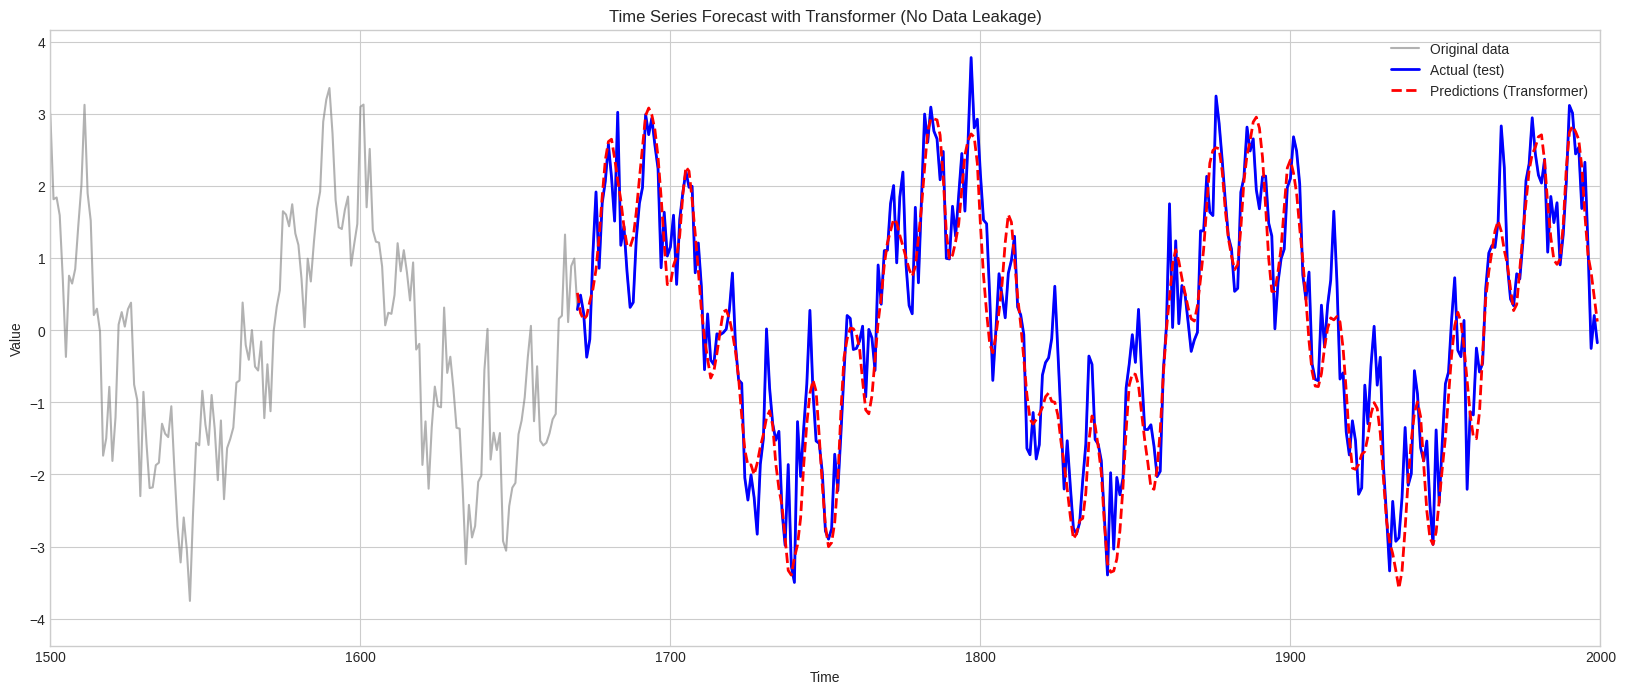

In [31]:
plt.figure(figsize = (20, 8))

plt.plot(np.arange(len(series)), series, label = 'Original data', color = 'gray', alpha = 0.6)

test_start = len(series_train)
test_time_axis = np.arange(test_start + input_window, len(series))

plt.plot(test_time_axis, y_test_original, label = 'Actual (test)', color = 'blue', linewidth = 2)
plt.plot(test_time_axis, actual_predictions, label = 'Predictions (Transformer)', color = 'red', linestyle = '--', linewidth = 2)

plt.title("Time Series Forecast with Transformer (No Data Leakage)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.xlim(test_start - 100, len(series))
plt.show()

# V - Deploy: autoregressive forecasting

In [32]:
def forecast_future(model, start_sequence, future_steps):
    """
    Autoregressive multi-step forecasting.
    Takes the last known window, predicts the next point,
    appends it to the window (dropping the oldest), and repeats.
    Note: errors accumulate over long horizons.
    """
    model.eval()
    future_predictions = []
    current_sequence = start_sequence.clone().detach()

    with torch.no_grad():
        for i in range(future_steps):
            # Predict next value from current window
            next_pred = model(current_sequence.unsqueeze(0))
            future_predictions.append(next_pred.item())

            # Shift window: drop oldest point, append prediction
            next_pred_tensor = torch.tensor([[next_pred.item()]], device = device)
            current_sequence = torch.cat((current_sequence[1:], next_pred_tensor), dim = 0)

    return np.array(future_predictions)

In [33]:
# Use the last test sequence as starting point for future forecast
last_sequence_real = X_test[-1].to(device)
steps_to_forecast  = 200

# Generate and inverse-transform the forecast
future_forecast_normalized = forecast_future(forecast_model, last_sequence_real, steps_to_forecast)
future_forecast = scaler.inverse_transform(future_forecast_normalized.reshape(-1, 1))

Let's visualize everything together: historical data, test predictions, and future forecast.

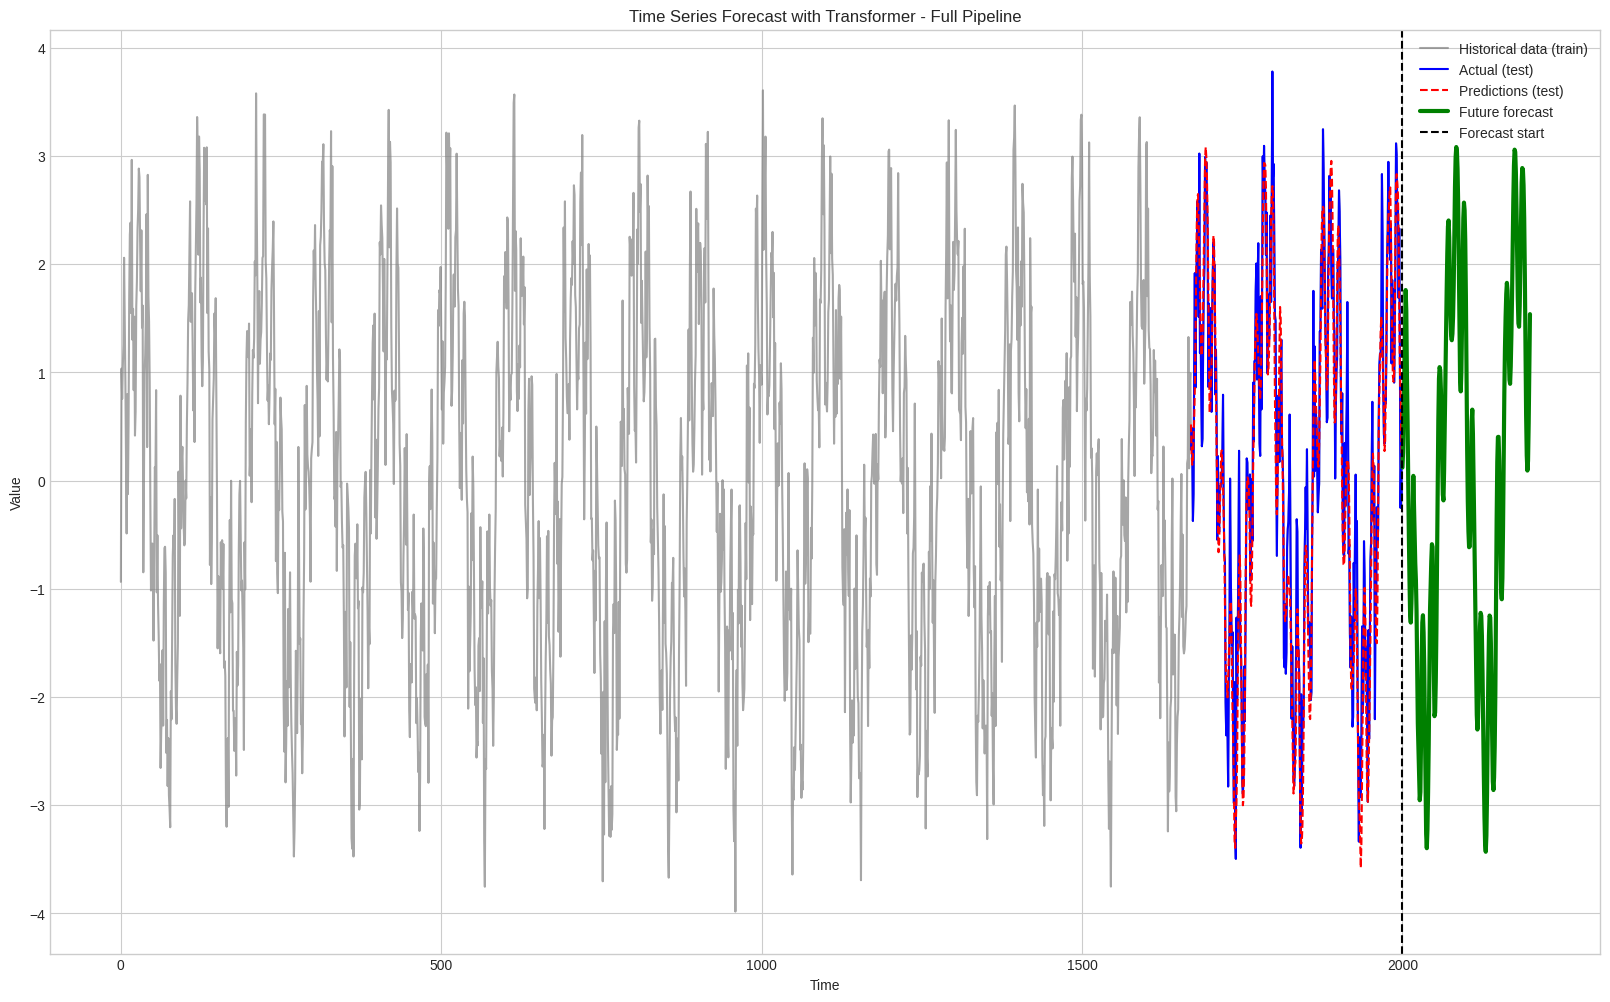

In [34]:
plt.figure(figsize = (20, 12))

# Full historical series
plt.plot(np.arange(len(series)), series, label = 'Historical data (train)', color = 'gray', alpha = 0.7)

# Test set: actuals vs predictions
test_start = len(series_train)
test_time_axis = np.arange(test_start + input_window, len(series))
plt.plot(test_time_axis, y_test_original, label = 'Actual (test)', color = 'blue')
plt.plot(test_time_axis, actual_predictions, label = 'Predictions (test)', color = 'red', linestyle = '--')

# Future forecast
future_time_axis = np.arange(len(series), len(series) + steps_to_forecast)
plt.plot(future_time_axis, future_forecast, label = 'Future forecast', color = 'green', linewidth = 3)

# Vertical line marking the start of the forecast
plt.axvline(x = len(series) - 1, color = 'black', linestyle = '--', label = 'Forecast start')

plt.title("Time Series Forecast with Transformer - Full Pipeline")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# VI - Applying to real-world data: daily gold prices

Now we apply the same Transformer pipeline to real financial data: **daily gold fixing prices** (USD per Troy ounce) from the London Bullion Market, spanning January 1995 to November 2016.

This tests whether the model can learn patterns in non-periodic, trend-driven data - a much harder task than synthetic sinusoids. We create a fresh model, scaler, and optimizer to ensure complete separation from the synthetic experiment.

**Data source**: [TTU Time Series Data Repository](https://www.math.ttu.edu/~atrindad/tsdata/)

In [35]:
gold_data = pd.read_csv("./Gold.csv", sep = ',')
gold_data.head()

,DATE,VALUE
0,1995-01-03,381.40
1,1995-01-04,378.25
2,1995-01-05,375.00
3,1995-01-06,375.90
4,1995-01-09,372.45


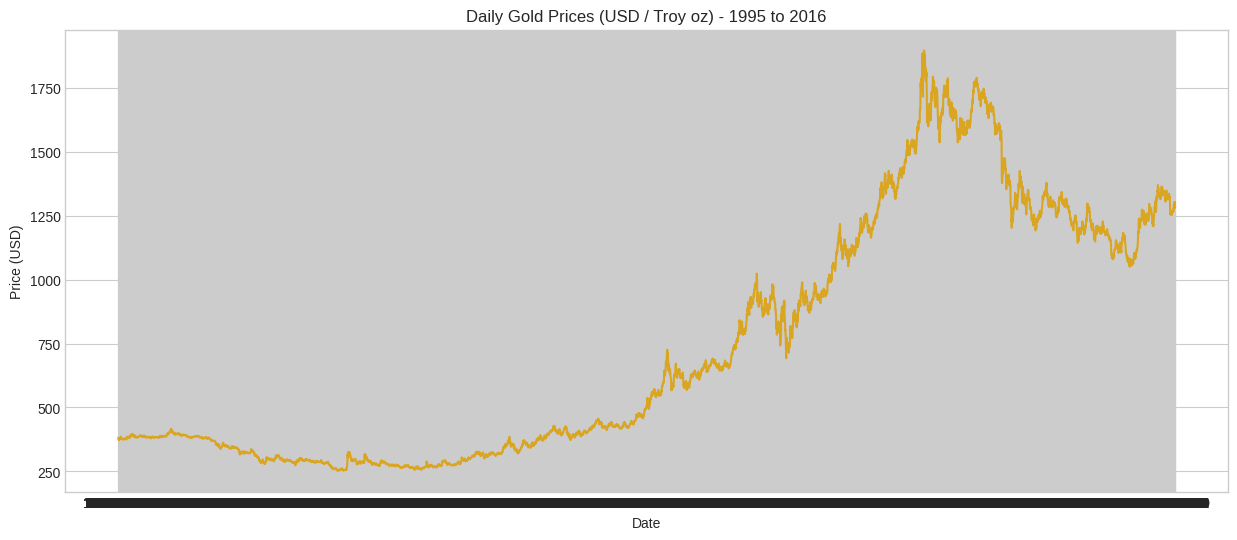

In [36]:
time        = gold_data['DATE']
gold_series = gold_data['VALUE']

plt.figure(figsize = (15, 6))
plt.plot(time, gold_series, color = 'goldenrod', linewidth = 1.5)
plt.title("Daily Gold Prices (USD / Troy oz) - 1995 to 2016")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

In [37]:
# Convert to numpy array for processing
gold_series = np.array(gold_series, dtype = np.float64)

In [38]:
# 80/20 sequential split
cutoff = int(len(gold_series) * 0.8)
gold_series_train = gold_series[:cutoff]
gold_series_test  = gold_series[cutoff:]

# Fresh scaler - fit ONLY on training data, range (-1, 1) to match PE scale
gold_scaler = MinMaxScaler(feature_range = (-1, 1))
gold_scaler.fit(gold_series_train.reshape(-1, 1))

gold_series_train_rescaled = gold_scaler.transform(gold_series_train.reshape(-1, 1)).astype(np.float32)
gold_series_test_rescaled  = gold_scaler.transform(gold_series_test.reshape(-1, 1)).astype(np.float32)

print(f"Train size: {len(gold_series_train)}, Test size: {len(gold_series_test)}")

Train size: 4420, Test size: 1106


In [39]:
# Reuse the same window size and sequence creation functions
gold_input_window = 70

gold_train_seqs = create_seqs(gold_series_train_rescaled, gold_input_window)
gold_test_seqs  = create_seqs(gold_series_test_rescaled,  gold_input_window)

X_train_gold, y_train_gold = convert_2_tensor(gold_train_seqs)
X_test_gold,  y_test_gold  = convert_2_tensor(gold_test_seqs)

print(f"Train sequences: {len(gold_train_seqs)}, Test sequences: {len(gold_test_seqs)}")

Train sequences: 4350, Test sequences: 1036


In [40]:
# DataLoaders for gold data
batch_size = 32

gold_train_dataset = TensorDataset(X_train_gold, y_train_gold)
gold_test_dataset  = TensorDataset(X_test_gold,  y_test_gold)

gold_train_loader = DataLoader(gold_train_dataset, batch_size = batch_size, shuffle = True)
gold_test_loader  = DataLoader(gold_test_dataset,  batch_size = batch_size, shuffle = False)

In [41]:
# Fresh model, criterion, and optimizer for gold data
gold_forecast_model = TimeSeriesTransformer().to(device)
gold_criterion      = nn.MSELoss()
gold_optimizer      = torch.optim.Adam(gold_forecast_model.parameters(), lr = 0.0005)

epochs = 50
gold_forecast_model.train()

TimeSeriesTransformer(
  (encoder): Linear(in_features=1, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=32, out_features=1, bias=True)
)

In [42]:
%%time

for epoch in range(epochs):
    total_loss = 0
    pbar = tqdm(gold_train_loader, desc = f"Epoch {epoch+1}/{epochs}")

    for seq, label in pbar:
        seq, label = seq.to(device), label.to(device)

        gold_optimizer.zero_grad()
        y_pred = gold_forecast_model(seq)
        loss = gold_criterion(y_pred, label.squeeze(-1))
        loss.backward()
        gold_optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(gold_train_loader)
    print(f"Epoch {epoch+1} completed, avg loss: {avg_loss:.6f}")

Epoch 1/50: 100%|██████████| 136/136 [00:20<00:00,  6.51it/s, loss=0.00219]


Epoch 1 completed, avg loss: 0.022633


Epoch 2/50: 100%|██████████| 136/136 [00:21<00:00,  6.20it/s, loss=0.00278]


Epoch 2 completed, avg loss: 0.002348


Epoch 3/50: 100%|██████████| 136/136 [00:20<00:00,  6.67it/s, loss=0.00434] 


Epoch 3 completed, avg loss: 0.002353


Epoch 4/50: 100%|██████████| 136/136 [00:21<00:00,  6.37it/s, loss=0.00123] 


Epoch 4 completed, avg loss: 0.002209


Epoch 5/50: 100%|██████████| 136/136 [00:20<00:00,  6.74it/s, loss=0.000928]


Epoch 5 completed, avg loss: 0.001987


Epoch 6/50: 100%|██████████| 136/136 [00:24<00:00,  5.53it/s, loss=0.00167] 


Epoch 6 completed, avg loss: 0.001754


Epoch 7/50: 100%|██████████| 136/136 [00:25<00:00,  5.42it/s, loss=0.00159] 


Epoch 7 completed, avg loss: 0.001585


Epoch 8/50: 100%|██████████| 136/136 [00:21<00:00,  6.21it/s, loss=0.000923]


Epoch 8 completed, avg loss: 0.001456


Epoch 9/50: 100%|██████████| 136/136 [00:22<00:00,  5.94it/s, loss=0.00349] 


Epoch 9 completed, avg loss: 0.001178


Epoch 10/50: 100%|██████████| 136/136 [00:23<00:00,  5.72it/s, loss=0.000685]


Epoch 10 completed, avg loss: 0.001237


Epoch 11/50: 100%|██████████| 136/136 [00:21<00:00,  6.42it/s, loss=0.00167] 


Epoch 11 completed, avg loss: 0.001545


Epoch 12/50: 100%|██████████| 136/136 [00:19<00:00,  6.80it/s, loss=0.00153] 


Epoch 12 completed, avg loss: 0.001221


Epoch 13/50: 100%|██████████| 136/136 [00:20<00:00,  6.57it/s, loss=0.000622]


Epoch 13 completed, avg loss: 0.000970


Epoch 14/50: 100%|██████████| 136/136 [00:20<00:00,  6.53it/s, loss=0.00118] 


Epoch 14 completed, avg loss: 0.001057


Epoch 15/50: 100%|██████████| 136/136 [00:20<00:00,  6.78it/s, loss=0.000951]


Epoch 15 completed, avg loss: 0.001224


Epoch 16/50: 100%|██████████| 136/136 [00:20<00:00,  6.73it/s, loss=0.0012]  


Epoch 16 completed, avg loss: 0.001155


Epoch 17/50: 100%|██████████| 136/136 [00:20<00:00,  6.50it/s, loss=0.00215] 


Epoch 17 completed, avg loss: 0.001179


Epoch 18/50: 100%|██████████| 136/136 [00:19<00:00,  6.91it/s, loss=0.00064] 


Epoch 18 completed, avg loss: 0.000886


Epoch 19/50: 100%|██████████| 136/136 [00:20<00:00,  6.69it/s, loss=0.000999]


Epoch 19 completed, avg loss: 0.000968


Epoch 20/50: 100%|██████████| 136/136 [00:19<00:00,  6.91it/s, loss=0.00112] 


Epoch 20 completed, avg loss: 0.000790


Epoch 21/50: 100%|██████████| 136/136 [00:19<00:00,  6.98it/s, loss=0.000996]


Epoch 21 completed, avg loss: 0.000845


Epoch 22/50: 100%|██████████| 136/136 [00:19<00:00,  6.85it/s, loss=0.00201] 


Epoch 22 completed, avg loss: 0.000914


Epoch 23/50: 100%|██████████| 136/136 [00:22<00:00,  6.14it/s, loss=0.000509]


Epoch 23 completed, avg loss: 0.000859


Epoch 24/50: 100%|██████████| 136/136 [00:22<00:00,  6.14it/s, loss=0.000547]


Epoch 24 completed, avg loss: 0.000795


Epoch 25/50: 100%|██████████| 136/136 [00:22<00:00,  6.00it/s, loss=0.000311]


Epoch 25 completed, avg loss: 0.000864


Epoch 26/50: 100%|██████████| 136/136 [00:19<00:00,  7.12it/s, loss=0.000547]


Epoch 26 completed, avg loss: 0.000811


Epoch 27/50: 100%|██████████| 136/136 [00:19<00:00,  7.09it/s, loss=0.000599]


Epoch 27 completed, avg loss: 0.000904


Epoch 28/50: 100%|██████████| 136/136 [00:18<00:00,  7.22it/s, loss=0.000531]


Epoch 28 completed, avg loss: 0.000815


Epoch 29/50: 100%|██████████| 136/136 [00:19<00:00,  6.96it/s, loss=0.00147] 


Epoch 29 completed, avg loss: 0.000886


Epoch 30/50: 100%|██████████| 136/136 [00:17<00:00,  7.62it/s, loss=0.00128] 


Epoch 30 completed, avg loss: 0.000810


Epoch 31/50: 100%|██████████| 136/136 [00:19<00:00,  6.90it/s, loss=0.000863]


Epoch 31 completed, avg loss: 0.000764


Epoch 32/50: 100%|██████████| 136/136 [00:19<00:00,  6.97it/s, loss=0.000542]


Epoch 32 completed, avg loss: 0.000816


Epoch 33/50: 100%|██████████| 136/136 [00:19<00:00,  6.92it/s, loss=0.000447]


Epoch 33 completed, avg loss: 0.000793


Epoch 34/50: 100%|██████████| 136/136 [00:20<00:00,  6.60it/s, loss=0.000358]


Epoch 34 completed, avg loss: 0.000738


Epoch 35/50: 100%|██████████| 136/136 [00:20<00:00,  6.80it/s, loss=0.000496]


Epoch 35 completed, avg loss: 0.000699


Epoch 36/50: 100%|██████████| 136/136 [00:19<00:00,  6.92it/s, loss=0.000303]


Epoch 36 completed, avg loss: 0.000679


Epoch 37/50: 100%|██████████| 136/136 [00:19<00:00,  6.81it/s, loss=0.000525]


Epoch 37 completed, avg loss: 0.000725


Epoch 38/50: 100%|██████████| 136/136 [00:21<00:00,  6.41it/s, loss=0.000765]


Epoch 38 completed, avg loss: 0.000720


Epoch 39/50: 100%|██████████| 136/136 [00:20<00:00,  6.48it/s, loss=0.000544]


Epoch 39 completed, avg loss: 0.000721


Epoch 40/50: 100%|██████████| 136/136 [00:20<00:00,  6.56it/s, loss=0.0009]  


Epoch 40 completed, avg loss: 0.000795


Epoch 41/50: 100%|██████████| 136/136 [00:23<00:00,  5.72it/s, loss=0.00142] 


Epoch 41 completed, avg loss: 0.000664


Epoch 42/50: 100%|██████████| 136/136 [00:24<00:00,  5.47it/s, loss=0.00051] 


Epoch 42 completed, avg loss: 0.000777


Epoch 43/50: 100%|██████████| 136/136 [00:22<00:00,  5.92it/s, loss=0.000725]


Epoch 43 completed, avg loss: 0.000772


Epoch 44/50: 100%|██████████| 136/136 [00:22<00:00,  5.96it/s, loss=0.00127] 


Epoch 44 completed, avg loss: 0.000598


Epoch 45/50: 100%|██████████| 136/136 [00:22<00:00,  6.11it/s, loss=0.000451]


Epoch 45 completed, avg loss: 0.000663


Epoch 46/50: 100%|██████████| 136/136 [00:22<00:00,  6.18it/s, loss=0.000983]


Epoch 46 completed, avg loss: 0.000694


Epoch 47/50: 100%|██████████| 136/136 [00:22<00:00,  6.17it/s, loss=0.000783]


Epoch 47 completed, avg loss: 0.000820


Epoch 48/50: 100%|██████████| 136/136 [00:25<00:00,  5.34it/s, loss=0.00148] 


Epoch 48 completed, avg loss: 0.000640


Epoch 49/50: 100%|██████████| 136/136 [00:26<00:00,  5.21it/s, loss=0.000319]


Epoch 49 completed, avg loss: 0.000641


Epoch 50/50: 100%|██████████| 136/136 [00:23<00:00,  5.73it/s, loss=0.00039] 

Epoch 50 completed, avg loss: 0.000543
CPU times: user 2h 11min 40s, sys: 2min 36s, total: 2h 14min 17s
Wall time: 17min 45s


In [43]:
# Evaluate on gold test set
gold_forecast_model.eval()

gold_predictions = []
gold_actuals = []

with torch.no_grad():
    for seq, label in gold_test_loader:
        seq, label = seq.to(device), label.to(device)
        y_pred = gold_forecast_model(seq)
        gold_predictions.extend(y_pred.cpu().numpy())
        gold_actuals.extend(label.cpu().numpy())

# Inverse transform using the gold-specific scaler
gold_actual_predictions = gold_scaler.inverse_transform(np.array(gold_predictions))
gold_y_test_original    = gold_scaler.inverse_transform(np.array(gold_actuals).reshape(-1, 1))

In [44]:
mse  = mean_squared_error(gold_y_test_original, gold_actual_predictions)
rmse = mse ** 0.5
mae  = mean_absolute_error(gold_y_test_original, gold_actual_predictions)

print(f"Gold prices - Test set metrics:")
print(f"  MSE:  {mse:.2f}")
print(f"  RMSE: {rmse:.2f} USD")
print(f"  MAE:  {mae:.2f} USD")

Gold prices - Test set metrics:
  MSE:  792.44
  RMSE: 28.15 USD
  MAE:  19.28 USD


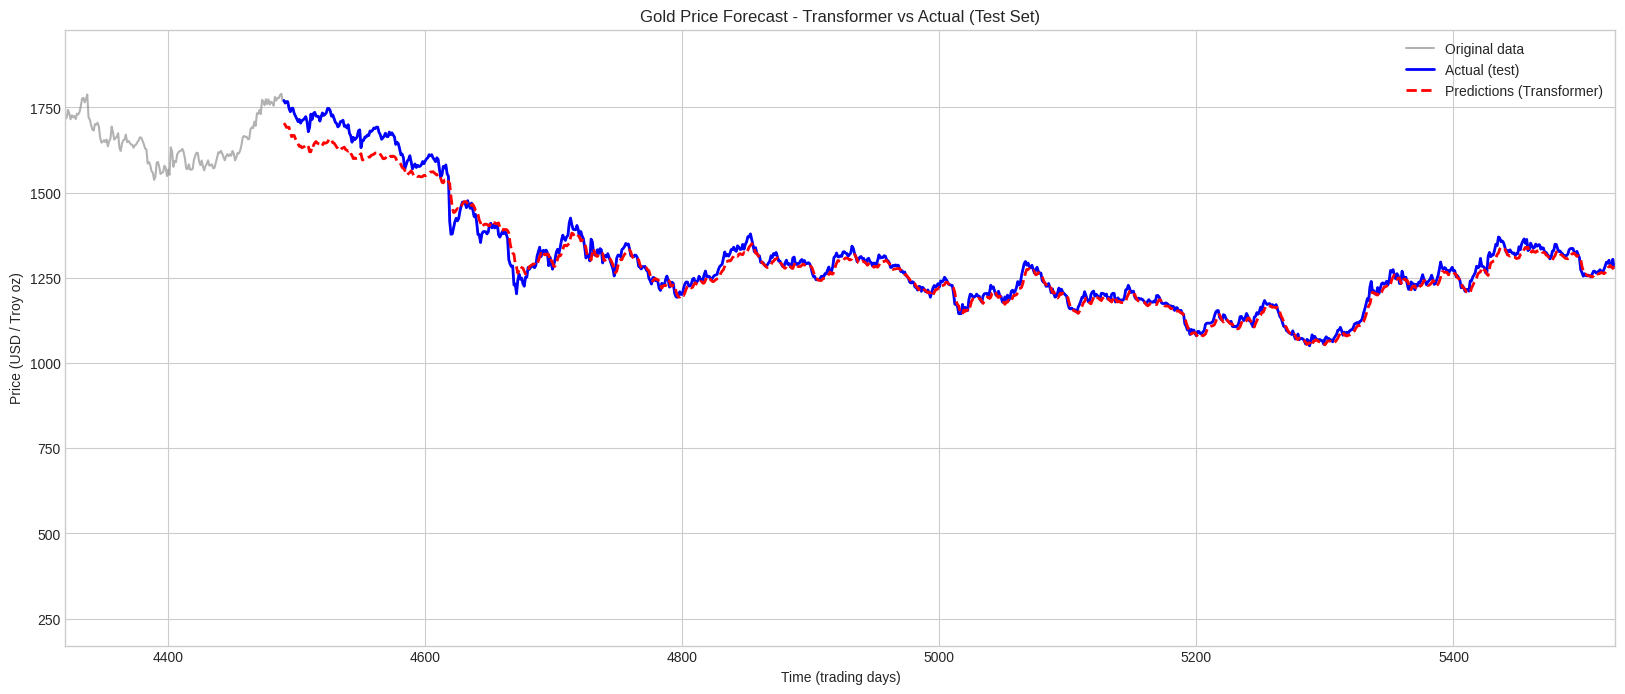

In [45]:
plt.figure(figsize = (20, 8))

plt.plot(np.arange(len(gold_series)), gold_series, label = 'Original data', color = 'gray', alpha = 0.6)

test_start = len(gold_series_train)
test_time_axis = np.arange(test_start + gold_input_window, len(gold_series))

plt.plot(test_time_axis, gold_y_test_original, label = 'Actual (test)', color = 'blue', linewidth = 2)
plt.plot(test_time_axis, gold_actual_predictions, label = 'Predictions (Transformer)', color = 'red', linestyle = '--', linewidth = 2)

plt.title("Gold Price Forecast - Transformer vs Actual (Test Set)")
plt.xlabel("Time (trading days)")
plt.ylabel("Price (USD / Troy oz)")
plt.legend()
plt.grid(True)
plt.xlim(test_start - 100, len(gold_series))
plt.show()

In [46]:
# Autoregressive forecast using the gold model
last_sequence_gold = X_test_gold[-1].to(device)
steps_to_forecast  = 200

# FIXED: forecast_future now correctly uses the 'model' parameter internally
gold_future_normalized = forecast_future(gold_forecast_model, last_sequence_gold, steps_to_forecast)
gold_future_forecast   = gold_scaler.inverse_transform(gold_future_normalized.reshape(-1, 1))

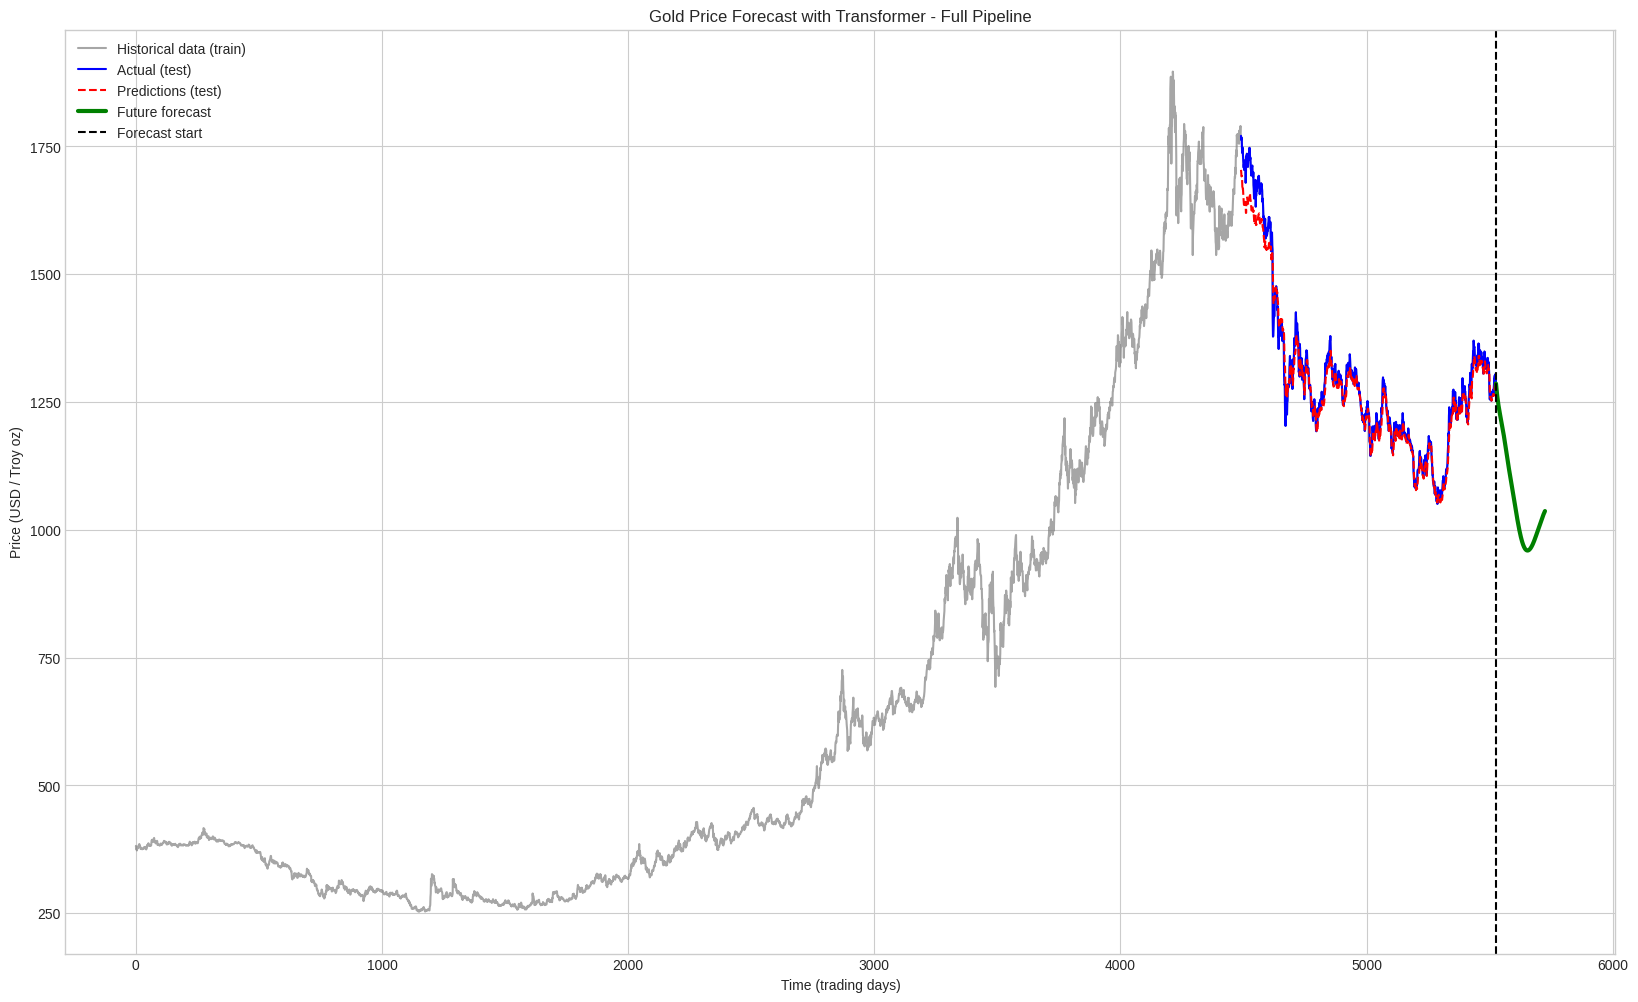

In [47]:
plt.figure(figsize = (20, 12))

plt.plot(np.arange(len(gold_series)), gold_series, label = 'Historical data (train)', color = 'gray', alpha = 0.7)

test_start = len(gold_series_train)
test_time_axis = np.arange(test_start + gold_input_window, len(gold_series))

plt.plot(test_time_axis, gold_y_test_original, label = 'Actual (test)', color = 'blue')
plt.plot(test_time_axis, gold_actual_predictions, label = 'Predictions (test)', color = 'red', linestyle = '--')

future_time_axis = np.arange(len(gold_series), len(gold_series) + steps_to_forecast)
plt.plot(future_time_axis, gold_future_forecast, label = 'Future forecast', color = 'green', linewidth = 3)

plt.axvline(x = len(gold_series) - 1, color = 'black', linestyle = '--', label = 'Forecast start')

plt.title("Gold Price Forecast with Transformer - Full Pipeline")
plt.xlabel("Time (trading days)")
plt.ylabel("Price (USD / Troy oz)")
plt.legend()
plt.grid(True)
plt.show()